In [1]:
import numpy as np
import pandas as pd
import arff
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from autofeat import AutoFeatRegressor 
import featuretools as ft


In [2]:
df = pd.read_csv('../data/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
from sklearn.metrics import accuracy_score, precision_score

def evaluate_classifier(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary') 
    confusion_mx = confusion_matrix(y_test, y_pred)
    
    return accuracy, precision,confusion_mx

In [4]:
X = df.drop(columns=["Outcome"])  
y = df["Outcome"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

logreg = LogisticRegression()
nb = GaussianNB()
rf = RandomForestClassifier(random_state=42)

acc_log, prec_log, mtrx_log,  = evaluate_classifier(logreg, X_train, y_train, X_test, y_test)
acc_nb, prec_nb, mtrx_nb,  = evaluate_classifier(nb, X_train, y_train, X_test, y_test)
acc_rf, prec_rf, mtrx_rf,  = evaluate_classifier(rf, X_train, y_train, X_test, y_test)


print("Logistic Regression: Accuracy = {:.2f}, Precision = {:.2f}".format(acc_log, prec_log))
print("Naive Bayes: Accuracy = {:.2f}, Precision = {:.2f}".format(acc_nb, prec_nb))
print("Random Forest: Accuracy = {:.2f}, Precision = {:.2f}".format(acc_rf, prec_rf))

Logistic Regression: Accuracy = 0.75, Precision = 0.65
Naive Bayes: Accuracy = 0.77, Precision = 0.66
Random Forest: Accuracy = 0.73, Precision = 0.62


In [ ]:
#affichage des matrices de confusion

print(f"LogisticRegression\n{mtrx_log}")
print(f"NaiveBayes\n{mtrx_nb}") 
print(f"RandomForest\n{mtrx_rf}")


LogisticRegression
[[79 20]
 [18 37]]
NaiveBayes
[[79 20]
 [16 39]]
RandomForest
[[78 21]
 [21 34]]


In [ ]:
#https://medium.com/@boukamchahamdi/autofeat-automating-feature-engineering-with-python-f22ec23265a9


af = AutoFeatRegressor(feateng_steps=2, n_jobs=-1)
X_train_af = af.fit_transform(X_train, y_train)
X_test_af = af.transform(X_test)




c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\autofeat\featsel.py:270: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  if np.max(np.abs(correlations[c].ravel()[:i])) < 0.9:


Nombre de nouvelles features créées : 15


c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [8]:
print(f"Nombre de nouvelles features créées : {X_train_af.shape[1] - X_train.shape[1]}")
X_train_af.head()

Nombre de nouvelles features créées : 15


,x000,x001,x002,x003,x004,x005,x006,x007,x001**4,x004/x000,...,x000**3/x003,x000*Abs(x004),x001*Abs(x002),Abs(x005)/x005,x002/x001,x000**2/x007,x001**3/x007,x001**2*x003,Abs(x006)/x006,x003**2*Abs(x002)
0,-0.547919,-1.154694,-3.572597,-1.288212,-0.692891,-4.060474,-0.507006,-1.041549,1.777734,1.264587,...,0.127691,-0.379648,-4.125255,-1.0,3.093979,-0.288239,1.478156,-1.717595,-1.0,5.928692
1,1.530847,-0.278373,0.666618,0.217261,-0.692891,-0.481351,2.446670,1.425995,0.006005,-0.452619,...,16.512498,1.060709,-0.185569,-1.0,-2.394691,1.643407,-0.015127,0.016836,1.0,0.031466
2,-0.844885,0.566649,-1.194501,-0.096379,0.027790,-0.417892,0.550035,-0.956462,0.103100,-0.032892,...,6.257635,-0.023479,0.676863,-1.0,-2.108006,-0.746324,-0.190229,-0.030947,1.0,0.011096
3,-1.141852,1.255187,-0.987710,-1.288212,-0.692891,-1.280942,-0.658012,2.702312,2.482180,0.606813,...,1.155690,-0.791178,1.239760,-1.0,-0.786903,0.482485,0.731795,-2.029570,-1.0,1.639095
4,0.639947,0.410164,0.563223,1.032726,2.519781,1.803195,-0.706334,1.085644,0.028303,3.937482,...,0.253774,1.612527,0.231014,1.0,1.373166,0.377225,0.063560,0.173740,-1.0,0.600690


In [10]:
logreg_af = LogisticRegression()
nb_af = GaussianNB()
rf_af = RandomForestClassifier(random_state=42)


acc_log_af, prec_log_af, mtrx_log_af = evaluate_classifier(logreg_af, X_train_af, y_train, X_test_af, y_test)
acc_nb_af, prec_nb_af, mtrx_nb_af = evaluate_classifier(nb_af, X_train_af, y_train, X_test_af, y_test)
acc_rf_af, prec_rf_af, mtrx_rf_af = evaluate_classifier(rf_af, X_train_af, y_train, X_test_af, y_test)



c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
print("Logistic Regression with AutoFeat: Accuracy = {:.2f}, Precision = {:.2f}".format(acc_log_af, prec_log_af))
print("Naive Bayes with AutoFeat: Accuracy = {:.2f}, Precision = {:.2f}".format(acc_nb_af, prec_nb_af))
print("Random Forest with AutoFeat: Accuracy = {:.2f}, Precision = {:.2f}".format(acc_rf_af, prec_rf_af))

  
print(f"LogisticRegression\n{mtrx_log_af}")
print(f"NaiveBayes\n{mtrx_nb_af}")
print(f"RandomForest\n{mtrx_rf_af}")

Logistic Regression with AutoFeat: Accuracy = 0.73, Precision = 0.63
Naive Bayes with AutoFeat: Accuracy = 0.71, Precision = 0.62
Random Forest with AutoFeat: Accuracy = 0.77, Precision = 0.71
LogisticRegression
[[81 18]
 [24 31]]
NaiveBayes
[[82 17]
 [27 28]]
RandomForest
[[85 14]
 [21 34]]


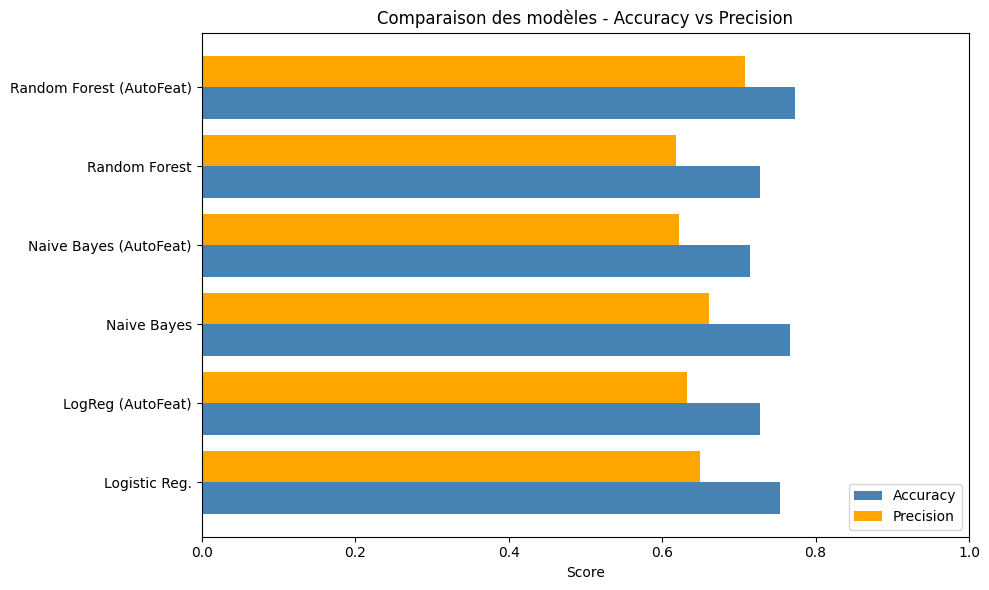

In [14]:
import matplotlib.pyplot as plt
import numpy as np


model_labels = [
    "Logistic Reg.", "LogReg (AutoFeat)", "Naive Bayes","Naive Bayes (AutoFeat)", "Random Forest",
     "Random Forest (AutoFeat)"
]


accuracy_values = [acc_log,acc_log_af , acc_nb, acc_nb_af, acc_rf, acc_rf_af]
precision_values = [prec_log, prec_log_af, prec_nb,prec_nb_af, prec_rf , prec_rf_af]

y = np.arange(len(model_labels))
bar_height = 0.4

fig, ax = plt.subplots(figsize=(10, 6))


ax.barh(y - bar_height/2, accuracy_values, height=bar_height, color='steelblue', label='Accuracy')


ax.barh(y + bar_height/2, precision_values, height=bar_height, color='orange', label='Precision')

# Axe Y
ax.set_yticks(y)
ax.set_yticklabels(model_labels)
ax.set_xlim(0, 1)
ax.set_xlabel("Score")
ax.set_title("Comparaison des modèles - Accuracy vs Precision")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()
